In [2]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scipy

data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)

xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [ ]:
#! NOTE: the hope is to put this in the preprocessing file later
# All three inputs are part of the outputs of the full_preprocessing() function
# xyz_clean: the normalized electrode locations cleaned out
# dropped: the actual voltage data with certain electrodes removed
# mapping_clean: this one i dont know
# this returns the list of the patient correlation matrices but only of the size for the 
# number of electrodes for that patients
def make_patient_correlation_matrix(xyz_clean,dropped,mapping_clean):
    #create RBF correlation matrix
    # Euclidean distance matrix (714x714)
    #dist_matrix = cdist(xyz_clean, xyz_clean, metric='euclidean')
    dist_matrix = scipy.spatial.distance.cdist(xyz_clean, xyz_clean, metric='euclidean')
    # Gaussian RBF kernel: exp(-(epsilon * r)^2)
    rbf_matrix = np.exp(-dist_matrix**2 / 20)

    correlation_matrices = []
    for i, matrix in enumerate(dropped): 
        # Get electrode indices for this patient
        patient_electrode_indices = mapping_clean[mapping_clean[:, 1] == i, 0].astype(int)   
        # Compute pairwise correlation between this patient's electrodes
        corr = pd.DataFrame(matrix).corr() #^ COLLECT THESE FOR JUST THE PATIENT CORRELTAION MATRIX

        correlation_matrices.append(corr)
    return correlation_matrices

In [3]:
correlation_matrices = make_rbf_correlation_matrix(xyz_clean,cleaned,mapping_clean)

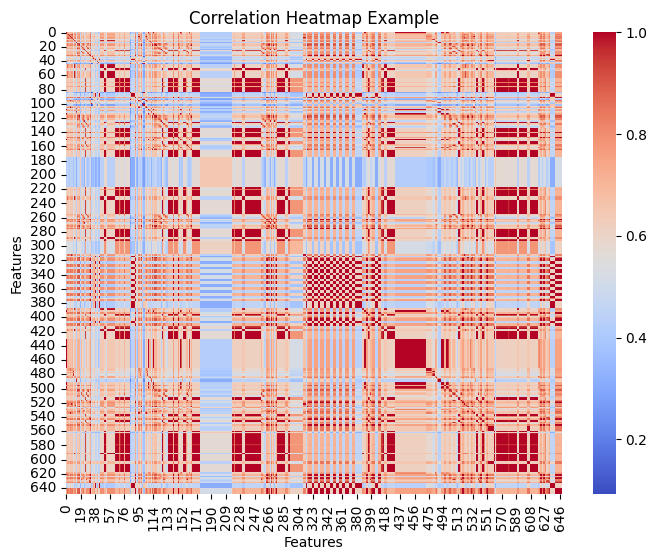

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrices[0], cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
num_nodes = 649
#k = int(num_nodes/20)
k = 10

clusters= KMeans(n_clusters=k, random_state=0, n_init="auto").fit(xyz_clean)
# knn 

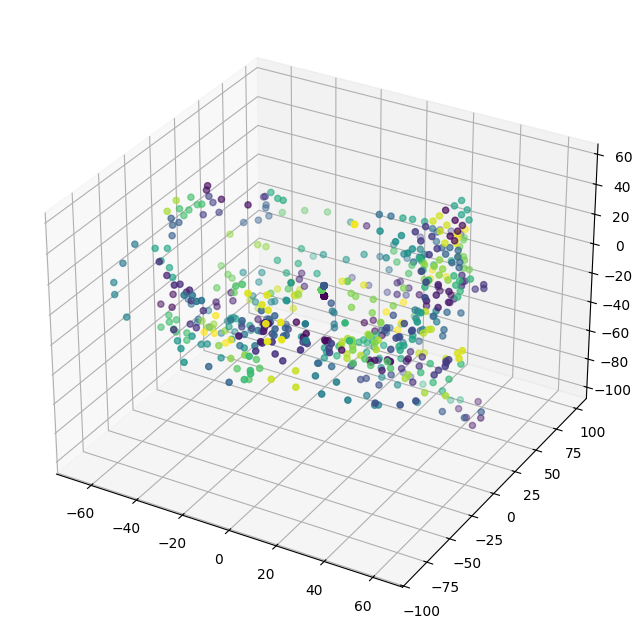

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xyz_clean[:,0],xyz_clean[:,1],xyz_clean[:,2], c=clusters.labels_) #, cmap='viridis'

# Graph of the nodes on the brain

In [16]:
from sklearn.neighbors import NearestNeighbors
k = 10
neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)

In [29]:
indicesofneigh = neigh.kneighbors()[1]
indicesofneigh.shape

(649, 10)

In [ ]:
from itertools import combinations
########################################################################################
all_pairs = []
for node in range(num_nodes): #for each node
    loc = xyz_clean[node] #gets the node location
    cluster = clusters.labels_[node] #gets the node cluster
    indices = np.where(clusters.labels_ == cluster) #gets the indices of all other nodes of the same cluster
    all_pairs.append(indices)



#now clear repeat clusters
cleaned_clusters = []
for cluster in all_pairs:
    do_we_pass = True
    for clust in cleaned_clusters:
        if np.array_equal(cluster,clust):
            do_we_pass = False
    if do_we_pass:
        cleaned_clusters.append(cluster)         
########################################################################################

# turn indices lists into pairwiase combos
all_edges = []
iter = 0
for indexs in indicesofneigh:
    #temp = []
    for num in indexs:
        all_edges.append((iter,num))
    iter += 1
    

#print(all_edges)
import networkx as nx
G = nx.Graph()
nodes = np.arange(num_nodes)
G.add_nodes_from(nodes)
G.add_edges_from(all_edges)

Glaplacian = nx.linalg.laplacian_matrix(G).toarray() #gets the laplacian of the bain graph for use to use

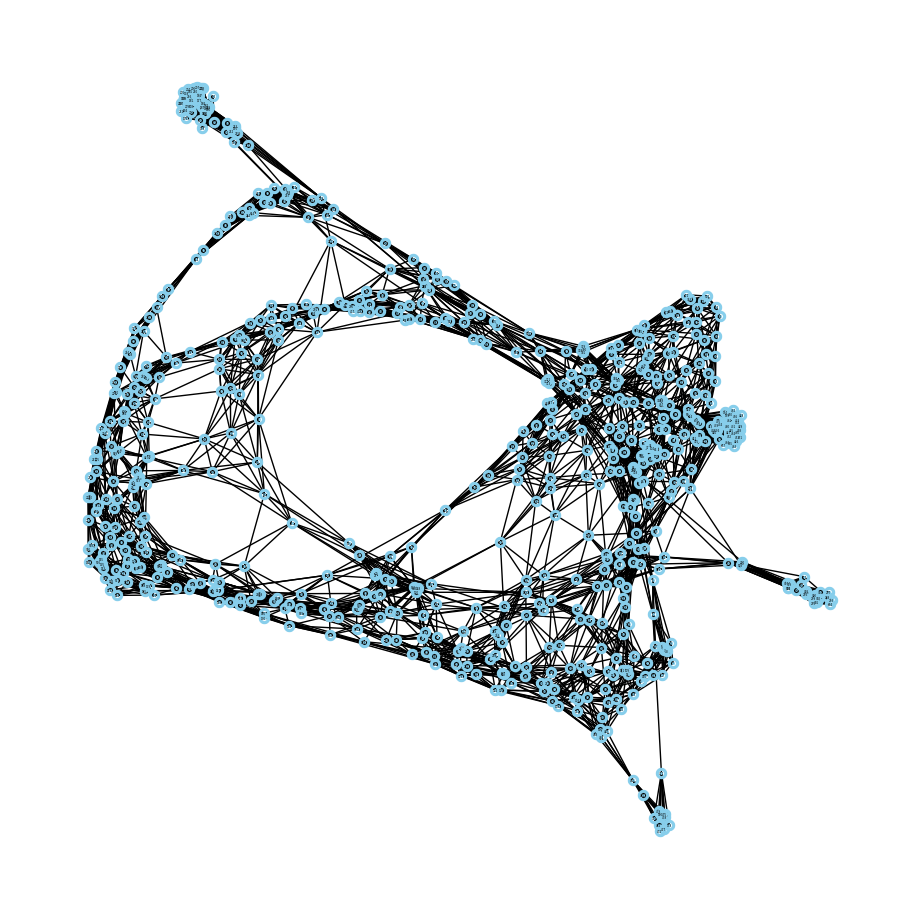

In [34]:
plt.figure(figsize=(9, 9))
pos = nx.spring_layout(G) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=5, edge_color='k', linewidths=6, font_size=2)
plt.show()

# PyTorch implementaion of our objective function

In [7]:
import torch
L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=True)
U = torch.rand((649,14*649),requires_grad=True)
C = torch.tensor(np.array(correlation_matrices),requires_grad=True)

def object_func(C,U,L):
    sum = torch.tensor(0,dtype=torch.float32,requires_grad=True)
    for i in range(14):
        c = C[i] #each patient correlation matrix
        u = U[:,i*649:i*649+649] #each u of big U
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 + 2*torch.trace(U.T@L@U)
    return sum

object_func(C,U,L)

tensor(1.5497e+11, dtype=torch.float64, grad_fn=<AddBackward0>)

In [10]:
optimizer = torch.optim.Adam([U], lr=0.01) 

for step in range(1000):
    print(step)
    optimizer.zero_grad()
    z = object_func(C,U,L)
    z.backward()
    optimizer.step()

0
1
2
3
4


KeyboardInterrupt: 

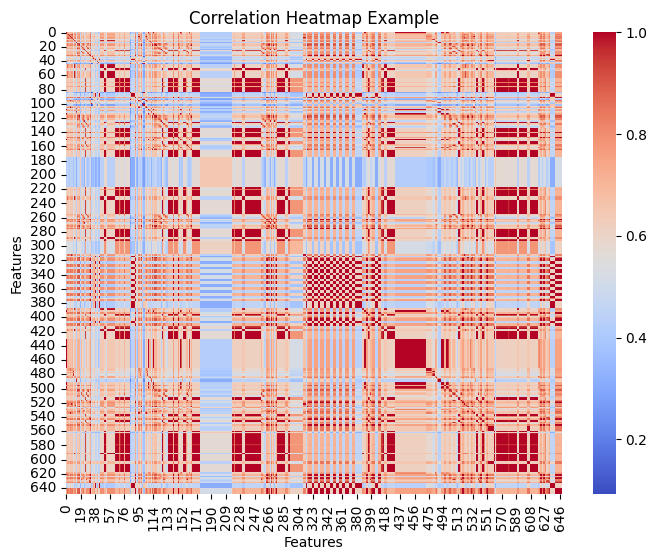

In [ ]:
# Big U is at least 649 rows tall, columns i think is 14*649
C[0]
plt.figure(figsize=(8, 6))
sns.heatmap(C[0], cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [115]:
U = torch.zeros((649,14*649))
U[:,0:14].shape

torch.Size([649, 14])

In [ ]:
#    2*torch.trace(U.T@Glaplacian@U)
#!  (torch.linalg.norm((u@u.T - c),ord='fro'))**2 + 2*torch.trace(U.T@L@U)
for i in range(14):
        c = C[i]
        u = U[:,i*649:i*649+649]

torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])
torch.Size([649, 649])


turn the kmeans in the knn beacuse thats what it should be, and connect nodes that are within its c closed 